In [116]:
import pandas as pd # Handling Data
import numpy as np # Handling Numbers
import seaborn as sns # Data Visuals
import matplotlib.pyplot as plt # Plots
from matplotlib.lines import lineStyles
from sklearn.preprocessing import StandardScaler
from scipy import stats

In [117]:
use_cols = ['assists', 'boosts', 'damageDealt', 'kills', 'killPoints'] # Using solo match related inputs for relevant model testing
pubg_dataset = pd.read_csv("C:\\Users\\Owner\\Desktop\\Comp Sci Year 3\\CS3072 Final Year Project\\archive\\pubg.csv")
pubg_dataset.head()
pubg_dataset.info()
pubg_dataset.duplicated()
# print(pubg_dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Id             1048575 non-null  object 
 1   groupId        1048575 non-null  object 
 2   matchId        1048575 non-null  object 
 3   assists        1048575 non-null  int64  
 4   boosts         1048575 non-null  int64  
 5   damageDealt    1048575 non-null  float64
 6   DBNOs          1048575 non-null  int64  
 7   headshotKills  1048575 non-null  int64  
 8   killPoints     1048575 non-null  int64  
 9   kills          1048575 non-null  int64  
 10  winPoints      1048575 non-null  int64  
 11  winPlacePerc   1048575 non-null  float64
dtypes: float64(2), int64(7), object(3)
memory usage: 96.0+ MB


0          False
1          False
2          False
3          False
4          False
           ...  
1048570    False
1048571    False
1048572    False
1048573    False
1048574    False
Length: 1048575, dtype: bool

In [118]:
# Handling dupes
print(f"Total rows: {len(pubg_dataset)}")
print(f"Duplicate rows: {pubg_dataset.duplicated().sum()}")

# Remove dupes
pubg_dataset = pubg_dataset.drop_duplicates()
print(f"Rows after removal: {len(pubg_dataset)}")

Total rows: 1048575
Duplicate rows: 0
Rows after removal: 1048575


In [119]:
# Calculate no. of players in each group for every match
pubg_dataset['group_size'] = pubg_dataset.groupby(['matchId', 'groupId'])['Id'].transform('count')

# Find the maximum group size that occurred in each match
match_max_group_size = pubg_dataset.groupby('matchId')['group_size'].transform('max')

# Creating new dataframes based on max size
solo_matches = pubg_dataset[match_max_group_size == 1].copy()
duo_matches = pubg_dataset[match_max_group_size == 2].copy()
squad_matches = pubg_dataset[match_max_group_size > 2].copy()

print(f"Solo rows: {len(solo_matches)}")
print(f"Duo rows: {len(duo_matches)}")
print(f"Squad rows: {len(squad_matches)}")

Solo rows: 154796
Duo rows: 424550
Squad rows: 469229


In [120]:
# Group solo matches by matchId
solo_by_match = {match_id: group for match_id, group in solo_matches.groupby('matchId')}

# Group duo matches by matchId
duo_by_match = {match_id: group for match_id, group in duo_matches.groupby('matchId')}

# Group squad matches by matchId
squad_by_match = {match_id: group for match_id, group in squad_matches.groupby('matchId')}

# Access individual matches like:
# solo_by_match['some_match_id']
print(f"Number of solo matches: {len(solo_by_match)}")
print(f"Number of duo matches: {len(duo_by_match)}")
print(f"Number of squad matches: {len(squad_by_match)}")

Number of solo matches: 7419
Number of duo matches: 20055
Number of squad matches: 20466


In [121]:
solo_matches['matchType'] = 'Solo'
duo_matches['matchType'] = 'Duo'
squad_matches['matchType'] = 'Squad'

all_matches = pd.concat([solo_matches, duo_matches, squad_matches], ignore_index=True)

solo_matches.to_csv("solo_pubgdf.csv", index=False)

In [122]:
# Summary Statistics Table

# Key variables for analysis
key_vars = ['damageDealt', 'kills', 'boosts', 'assists', 'headshotKills', 'winPlacePerc']

# Summary table
summary_stats = all_matches.groupby('matchType')[key_vars].agg(['mean', 'median', 'std'])
print(summary_stats.round(2))
print("\n")

          damageDealt                kills              boosts               \
                 mean median     std  mean median   std   mean median   std   
matchType                                                                     
Duo            133.70  86.86  172.97  0.94    0.0  1.58   1.13    0.0  1.73   
Solo           121.90  77.31  169.27  0.96    0.0  1.60   1.09    0.0  1.80   
Squad          131.31  84.38  170.35  0.90    0.0  1.53   1.10    0.0  1.68   

          assists              headshotKills              winPlacePerc         \
             mean median   std          mean median   std         mean median   
matchType                                                                       
Duo          0.24    0.0  0.58          0.23    0.0  0.60         0.49   0.48   
Solo         0.08    0.0  0.34          0.25    0.0  0.65         0.50   0.49   
Squad        0.28    0.0  0.65          0.22    0.0  0.58         0.45   0.43   

                 
            std  
ma

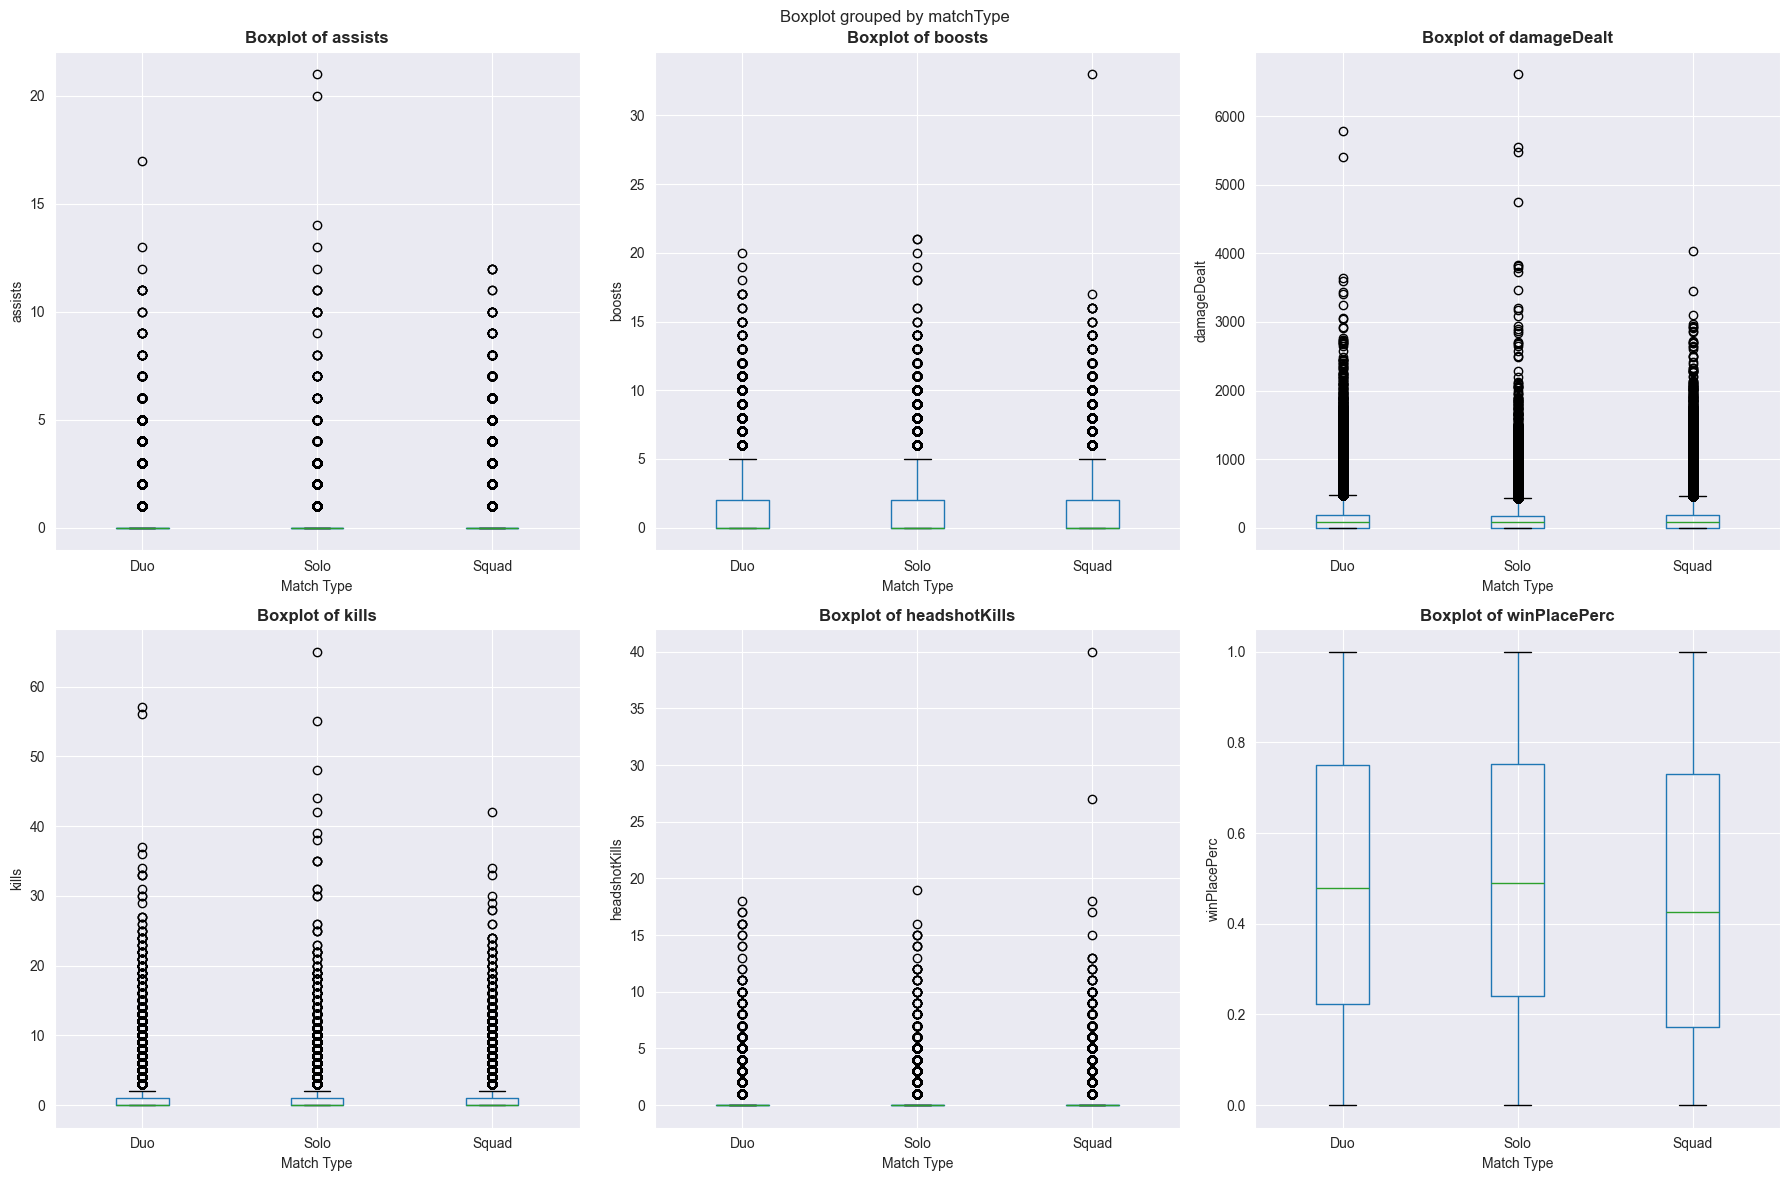

In [123]:
# Distribution Plot
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Key Variables by Match Type', fontsize=16, fontweight='bold')

variables = ['assists', 'boosts', 'damageDealt', 'kills', 'headshotKills', 'winPlacePerc']

for idx, var in enumerate(variables):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    # Create box plots
    all_matches.boxplot(column=var, by='matchType', ax=ax)
    ax.set_title(f'Boxplot of {var}', fontweight = 'bold')
    ax.set_xlabel('Match Type')
    ax.set_ylabel(var)
    plt.sca(ax)
    plt.xticks(rotation = 0)

plt.tight_layout()
plt.savefig('distribution_by_match_type.png', dpi = 300, bbox_inches = 'tight')
plt.show()


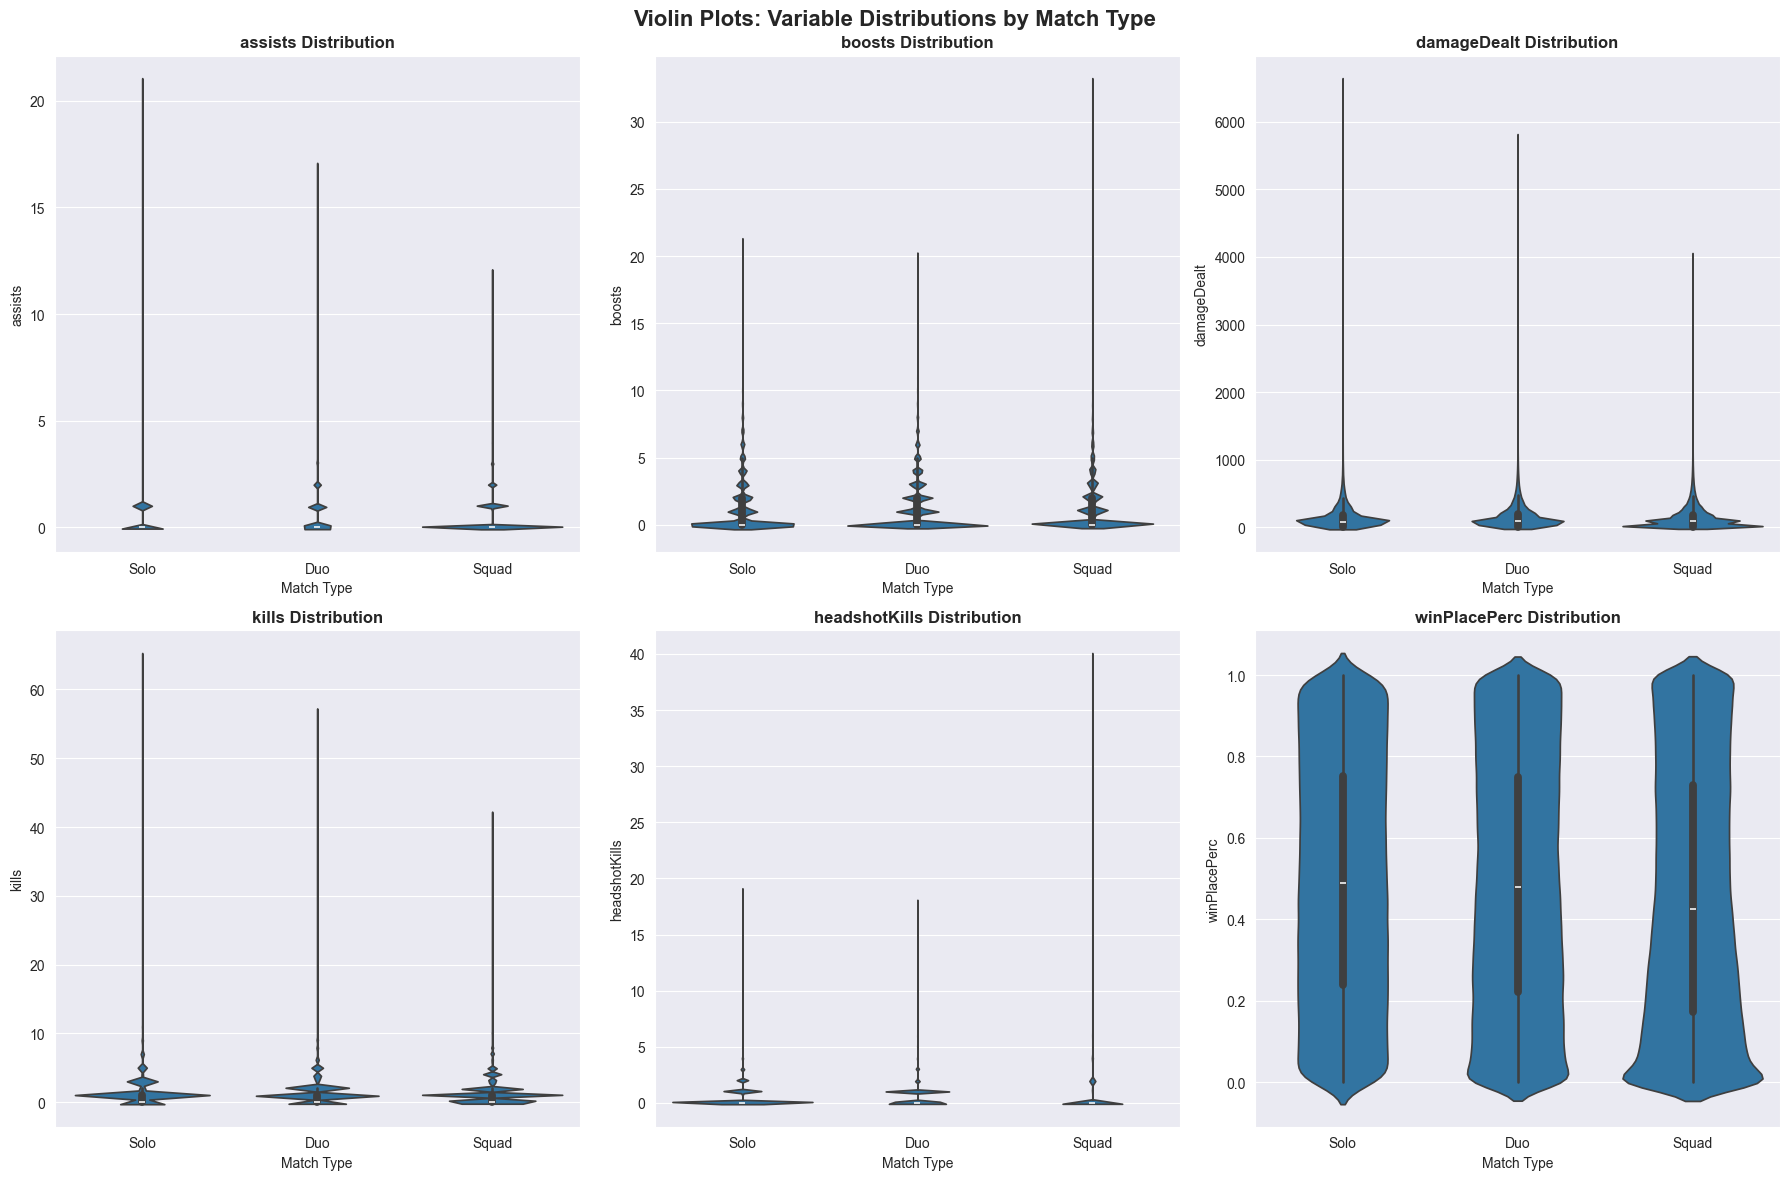

In [124]:
# Violin Plots for more detailed distributions

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Violin Plots: Variable Distributions by Match Type', fontsize=16, fontweight='bold')

for idx, var in enumerate(variables):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    sns.violinplot(data=all_matches, x='matchType', y=var, ax=ax)
    ax.set_title(f'{var} Distribution', fontweight = 'bold')
    ax.set_xlabel('Match Type')
    ax.set_ylabel(var)

plt.tight_layout()
plt.savefig('violin_plots_by_match_type.png', dpi = 300, bbox_inches = 'tight')
plt.show()

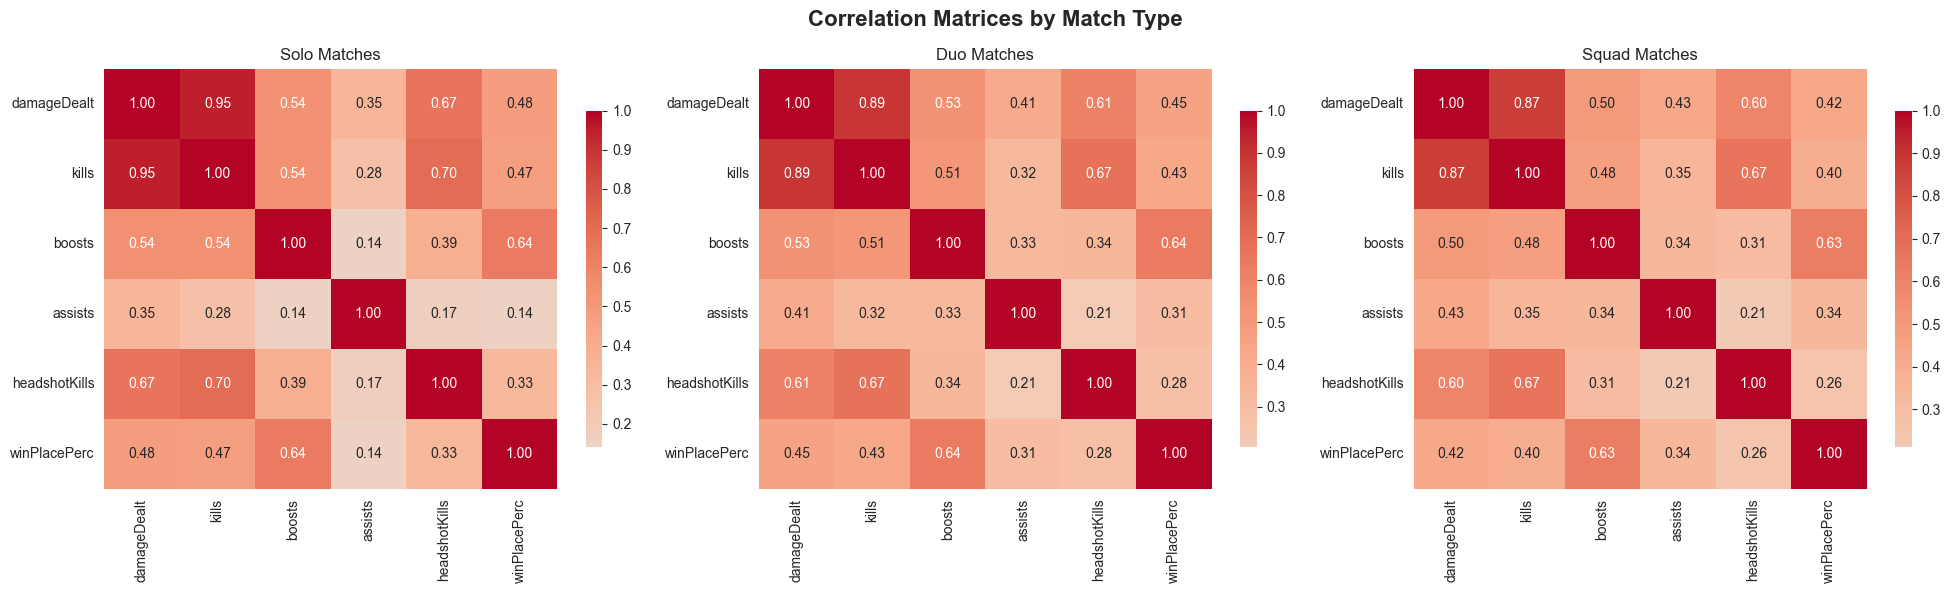

In [125]:
    # Correlation Heatmaps - For each match type

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Correlation Matrices by Match Type', fontsize=16, fontweight='bold')

match_types = [solo_matches, duo_matches, squad_matches]
titles = ['Solo Matches', 'Duo Matches', 'Squad Matches']

for idx, (matches, title) in enumerate(zip(match_types, titles)):
    # Select numeric columns
    numeric_cols = matches[key_vars].select_dtypes(include=[np.number])
    corr_matrix = numeric_cols.corr()

    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=axes[idx], cbar_kws={'shrink': 0.8})
    axes[idx].set_title(title)

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi = 300, bbox_inches = 'tight')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_35816\1942881444.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Owner\AppData\Local\Temp\ipykernel_35816\1942881444.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('scatter_plots_by_match_type.png', dpi = 300, bbox_inches = 'tight')


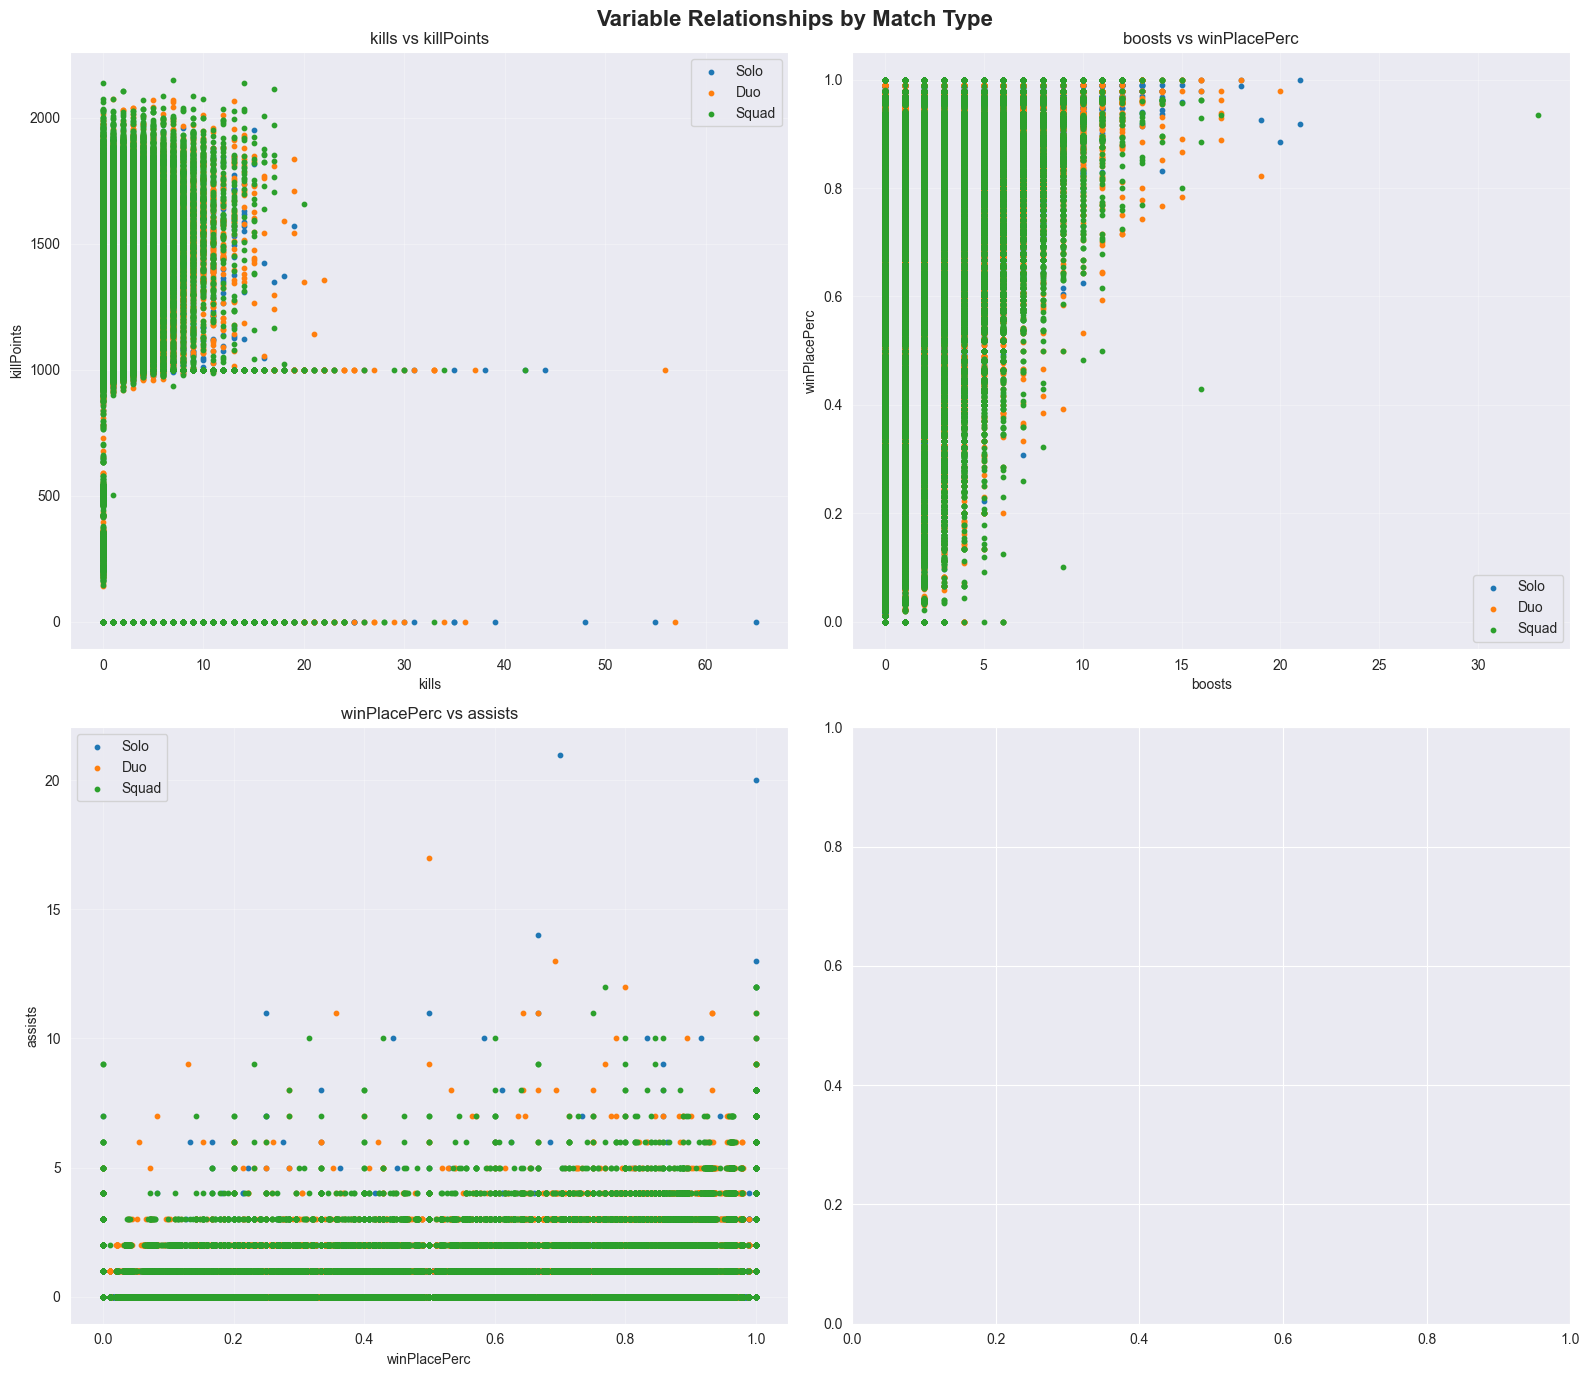

In [126]:
# Scatter Plots - Relationships between variables

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Variable Relationships by Match Type', fontsize=16, fontweight='bold')

scatter_pairs = [('kills', 'killPoints'),
                 ('boosts', 'winPlacePerc'),
                 ('winPlacePerc', 'assists')
]

for idx, (var1, var2) in enumerate(scatter_pairs):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]

    for match_types in ['Solo', 'Duo', 'Squad']:
        data = all_matches[all_matches['matchType'] == match_types]
        ax.scatter(data[var1], data[var2], label=match_types, s=10)

    ax.set_xlabel(var1)
    ax.set_ylabel(var2)
    ax.set_title(f'{var1} vs {var2}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_plots_by_match_type.png', dpi = 300, bbox_inches = 'tight')
plt.show()


Solo Match Summary
Total Players: 24
Average Kills: 1.12
Average Damage: 134.02
Average Headshot Kills: 1.12

Duo Match Summary
Total Players: 20
Average Kills: 1.05
Average Damage: 175.84
Average Headshot Kills: 1.05

Squad Match Summary
Total Players: 23
Average Kills: 0.74
Average Damage: 97.18
Average Headshot Kills: 0.74


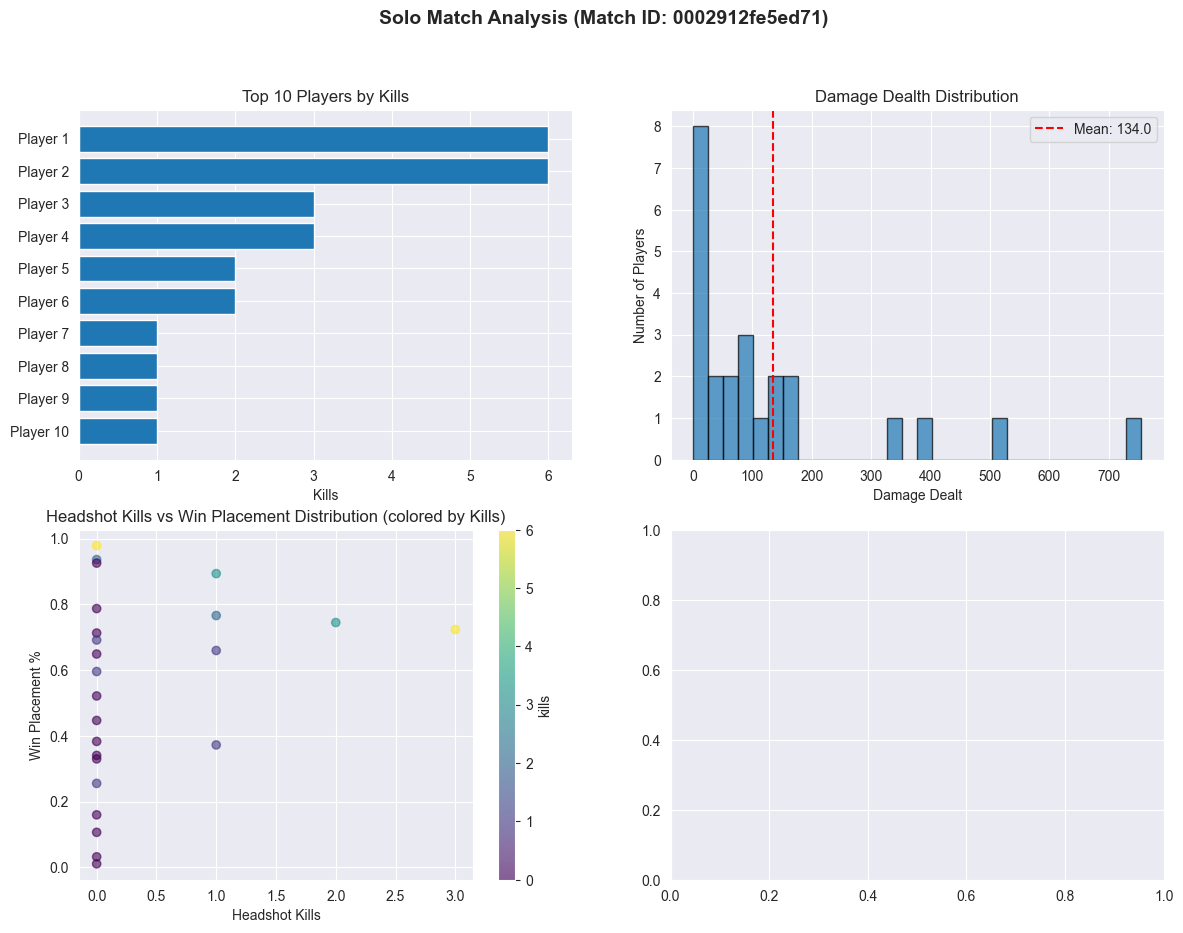

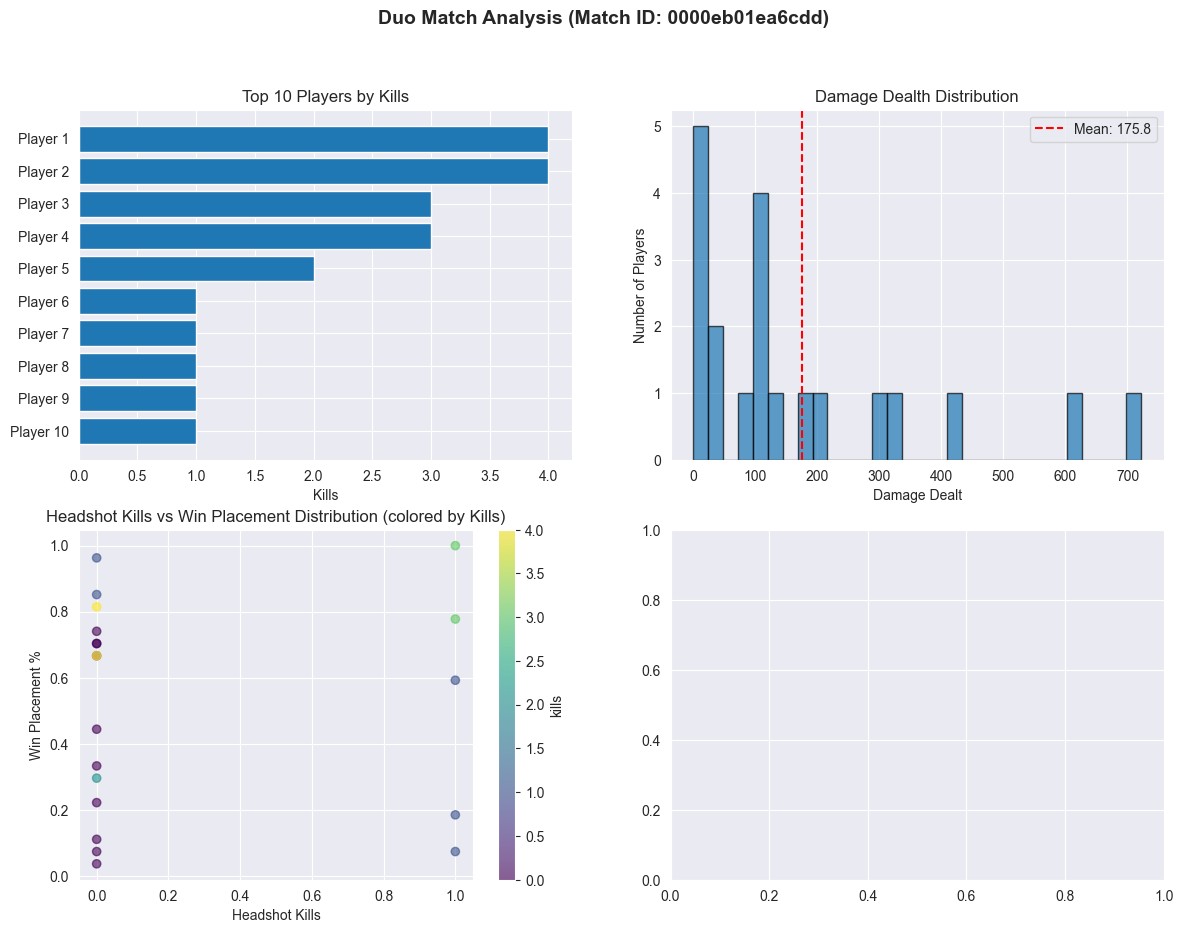

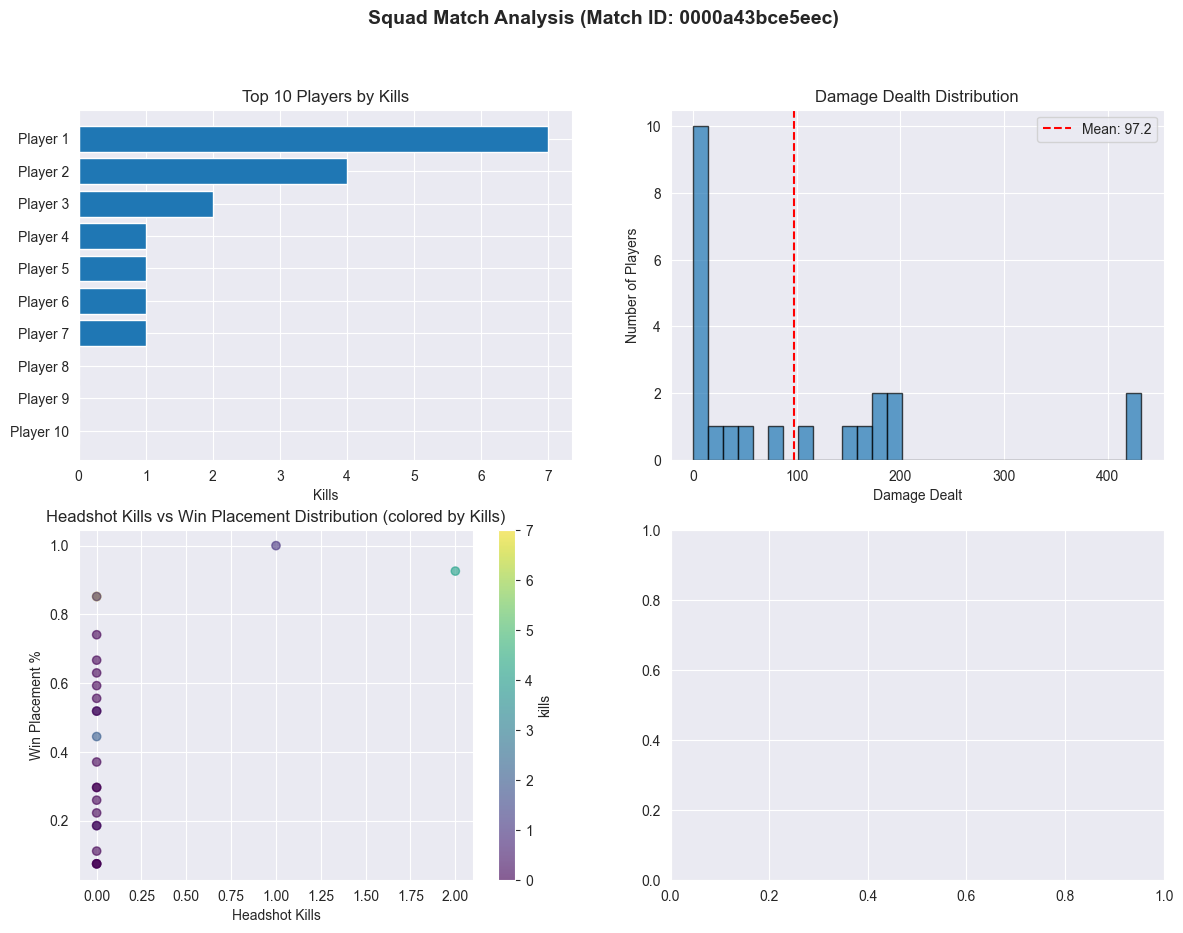

In [127]:
# Individual Match Analysis - First match of each type

def analyse_single_match(match_data, match_type):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'{match_type} Match Analysis (Match ID: {match_data["matchId"].iloc[0]})', fontsize=14, fontweight='bold')

    # 1) Top performers by kills
    ax1 = axes[0, 0]
    top_killers = match_data.nlargest(10, 'kills')[['Id', 'kills', 'damageDealt']]
    ax1.barh(range(len(top_killers)), top_killers['kills'])
    ax1.set_yticks(range(len(top_killers)))
    ax1.set_yticklabels(f"Player {i+1}" for i in range(len(top_killers)))
    ax1.set_xlabel('Kills')
    ax1.set_title('Top 10 Players by Kills')
    ax1.invert_yaxis()

    # 2) Damage dealt distribution
    ax2 = axes[0, 1]
    ax2.hist(match_data['damageDealt'], bins=30, edgecolor='black', alpha=0.7)
    ax2.axvline(match_data['damageDealt'].mean(), color='red', linestyle='--', label=f'Mean: {match_data["damageDealt"].mean():.1f}')
    ax2.set_xlabel('Damage Dealt')
    ax2.set_ylabel('Number of Players')
    ax2.set_title('Damage Dealth Distribution')
    ax2.legend()

    # 3) headshotKills vs winPlacePerc
    ax3 = axes[1, 0]
    scatter = ax3.scatter(match_data['headshotKills'], match_data['winPlacePerc'], c=match_data['kills'], cmap='viridis', alpha=0.6)
    ax3.set_xlabel('Headshot Kills')
    ax3.set_ylabel('Win Placement %')
    ax3.set_title('Headshot Kills vs Win Placement Distribution (colored by Kills)')
    plt.colorbar(scatter, ax=ax3, label='kills')

    # Print Summary
    print(f"\n{'='*30}")
    print(f"{match_type} Match Summary")
    print(f"{'='*30}")
    print(f"Total Players: {len(match_data)}")
    print(f"Average Kills: {match_data['kills'].mean():.2f}")
    print(f"Average Damage: {match_data['damageDealt'].mean():.2f}")
    print(f"Average Headshot Kills: {match_data['kills'].mean():.2f}")
    print(f"{'='*30}")

# Analyse first match of each type
solo_grouped = solo_matches.groupby('matchId')
duo_grouped = duo_matches.groupby('matchId')
squad_grouped = squad_matches.groupby('matchId')

# Get first match from each group
first_solo = next(iter(solo_grouped))[1]
first_duo = next(iter(duo_grouped))[1]
first_squad = next(iter(squad_grouped))[1]

analyse_single_match(first_solo, 'Solo')
analyse_single_match(first_duo, 'Duo')
analyse_single_match(first_squad, 'Squad')

In [128]:
# Comparative Table - Match Statistics

print("\n" + "="*30)
print("Match-Level Statistics")
print(f"{'='*30}")

match_stats = []
for match_types, grouped in [('Solo', solo_grouped), ('Duo', duo_grouped), ('Squad', squad_grouped)]:
    for match_id, match_data in grouped:
        match_stats.append({
            'match_type': match_types,
            'match_id': match_id,
            'num_players': len(match_data),
            'total_kills' : match_data['kills'].sum(),
            'avg_damage' : match_data['damageDealt'].mean(),
            'avg_headshotKills' : match_data['headshotKills'].mean(),
            'max_kills' : match_data['kills'].max(),
            'max_headshotKills' : match_data['headshotKills'].max(),
        })

match_summary = pd.DataFrame(match_stats)
print(match_summary.groupby('match_type').agg({
    'num_players' : ['mean', 'min', 'max'],
    'total_kills' : ['mean', 'std'],
    'avg_damage' : ['mean', 'std'],
    'avg_headshotKills' : ['mean', 'std'],
    'max_kills' : ['min', 'max']
}).round(2))

print(f"\n{'='*30}")
print("Analysis Complete.")
print(f"{'='*30}")


Match-Level Statistics
           num_players         total_kills       avg_damage          \
                  mean min max        mean   std       mean     std   
match_type                                                            
Duo              21.17   2  47       19.91  8.37     136.25   69.08   
Solo             20.86   1  41       19.94  8.51     132.59  149.39   
Squad            22.93   3  47       20.68  8.96     132.49   58.69   

           avg_headshotKills       max_kills      
                        mean   std       min max  
match_type                                        
Duo                     0.23  0.19         0  57  
Solo                    0.27  0.40         0  65  
Squad                   0.22  0.17         0  42  

Analysis Complete.


In [129]:
# Capping outliers

def cap_outliers(df, columns, lower_percentile=0.01, upper_percentile=0.99):
    df_capped = df.copy()

    for column in columns:
        lower_cap = df_capped[column].quantile(lower_percentile)
        upper_cap = df_capped[column].quantile(upper_percentile)

        n_lower = (df_capped[df_capped[column] < lower_cap]).sum()
        n_upper = (df_capped[df_capped[column] > upper_cap]).sum()

        print(f"\n{column}")
        print(f"  Capping {n_lower} values at lower: {lower_cap:.2f}")
        print(f"  Capping {n_upper} values at upper: {upper_cap:.2f}")

        df_capped[column] = df_capped[column].clip(lower=lower_cap, upper=upper_cap)

    return df_capped

# Columns to check for outliers

outlier_columns = ['kills', 'headshotKills', 'damageDealt', 'boosts']

In [130]:
# Scale Features
all_matches_processed = all_matches.drop_duplicates()
# Selecting the features to scale
features_to_scale = ['kills', 'headshotKills', 'damageDealt', 'boosts']

# Removing the columns that don't exist in dataset
features_to_scale = [col for col in features_to_scale if col in all_matches_processed.columns]
print(f"\nScaling features: {features_to_scale}")

scaler = StandardScaler()
all_matches_processed[features_to_scale] = scaler.fit_transform(
    all_matches_processed[features_to_scale]
)

print("\nFeatures after scaling (first 5 rows):")
print(all_matches_processed[features_to_scale].head())

print("\nScaling statistics:")
print(all_matches_processed[features_to_scale].describe())



Scaling features: ['kills', 'headshotKills', 'damageDealt', 'boosts']

Features after scaling (first 5 rows):
      kills  headshotKills  damageDealt    boosts
0  0.047742      -0.378902    -0.180316 -0.645502
1 -0.593272      -0.378902    -0.714242 -0.645502
2  1.970786       1.290512     1.128490 -0.062795
3  0.688757      -0.378902     0.720437  1.102617
4  0.047742      -0.378902     0.035094 -0.645502

Scaling statistics:
              kills  headshotKills   damageDealt        boosts
count  1.048575e+06   1.048575e+06  1.048575e+06  1.048575e+06
mean  -5.204175e-18   5.551120e-17  6.158274e-17  4.900598e-17
std    1.000000e+00   1.000000e+00  1.000000e+00  1.000000e+00
min   -5.932723e-01  -3.789020e-01 -7.640840e-01 -6.455016e-01
25%   -5.932723e-01  -3.789020e-01 -7.640840e-01 -6.455016e-01
50%   -5.932723e-01  -3.789020e-01 -2.717928e-01 -6.455016e-01
75%    4.774223e-02  -3.789020e-01  3.228912e-01  5.199106e-01
max    4.107267e+01   6.639765e+01  3.785798e+01  1.858380e+01


In [131]:
# Verify Preprocessing
print("Preprocessing summary:")

print(f"\nOriginal dataset: {len(all_matches)} rows")
print(f"Processed dataset: {len(all_matches_processed)} rows")
print(f"Features scaled: {len(features_to_scale)}")
print(f"\nDataset ready for machine learning!")

# Save processed data
all_matches_processed.to_csv('pubg_processed.csv', index=False)
print("\nProcessed data saved to 'pubg_processed.csv'")

Preprocessing summary:

Original dataset: 1048575 rows
Processed dataset: 1048575 rows
Features scaled: 4

Dataset ready for machine learning!

Processed data saved to 'pubg_processed.csv'


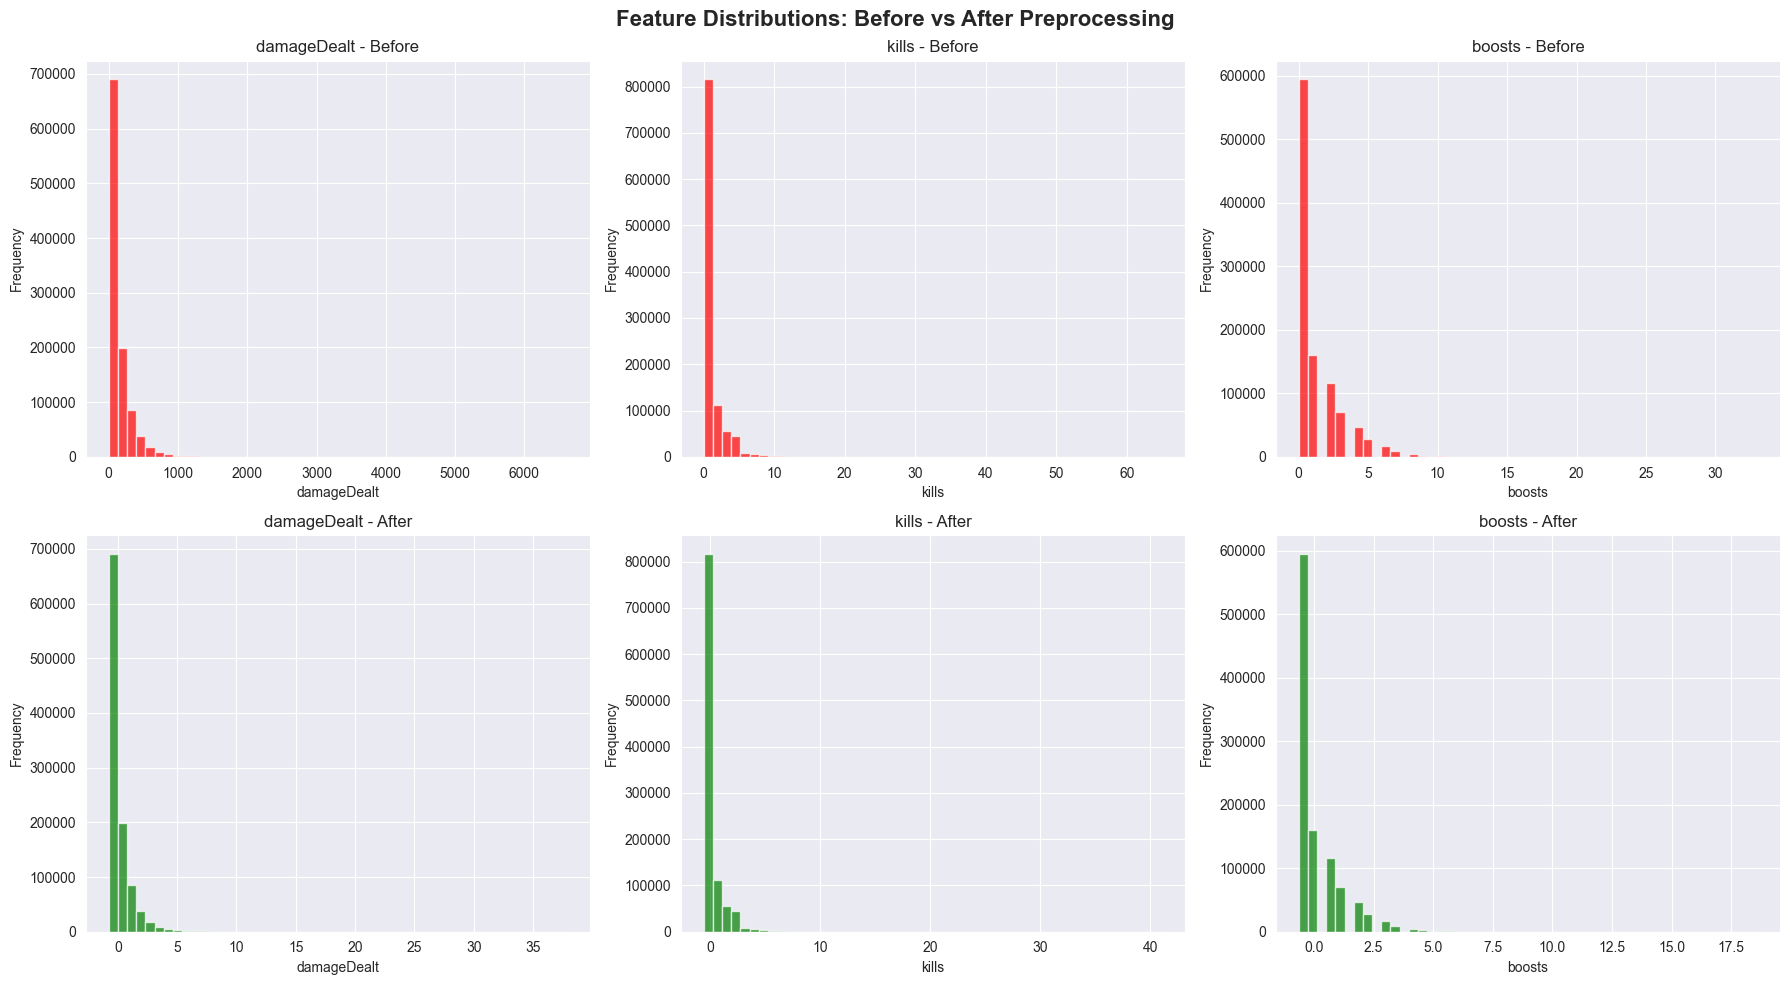

In [132]:
# Visualising before and after

# Compare distributions before and after
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Feature Distributions: Before vs After Preprocessing', fontsize=16, fontweight='bold')

sample_features = ['damageDealt', 'kills', 'boosts']

for idx, feature in enumerate(sample_features):
    # Before preprocessing
    ax1 = axes[0, idx]
    all_matches[feature].hist(bins=50, ax=ax1, alpha=0.7, color='red')
    ax1.set_title(f'{feature} - Before')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('Frequency')

    # After preprocessing
    ax2 = axes[1, idx]
    all_matches_processed[feature].hist(bins=50, ax=ax2, alpha=0.7, color='green')
    ax2.set_title(f'{feature} - After')
    ax2.set_xlabel(feature)
    ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('preprocessing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()